<a href="https://colab.research.google.com/github/lepccordeiro/InterUSS-Weather/blob/main/Projeto_Final_EBAC_Analista_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ======================================================
# INSTALAÇÃO DA BIBLIOTECA PYSPARK
#
# Objetivo:
# Instalar a biblioteca PySpark no ambiente
# Google Colab para permitir o processamento
# e análise de grandes volumes de dados
# utilizando computação distribuída.
#
# O que o código faz:
# - Baixa e instala a biblioteca PySpark;
# - Disponibiliza ferramentas para criação
#   de DataFrames e manipulação de dados;
# - Permite utilizar funções de análise
#   semelhantes ao Apache Spark.
#
# Importância para o projeto:
# O PySpark foi utilizado para realizar
# o tratamento, limpeza, transformação
# e análise exploratória das bases de
# Segurança Operacional.
# ======================================================

!pip install pyspark

In [6]:
# ======================================================
# INICIALIZAÇÃO DA SESSÃO SPARK
#
# Objetivo:
# Criar uma sessão do Apache Spark no ambiente
# Google Colab para permitir a execução das
# operações de processamento e análise de dados.
#
# O que o código faz:
# - Importa a classe SparkSession;
# - Cria uma sessão Spark chamada
#   "Painel_Risco_Aviacao";
# - Inicializa o ambiente necessário para
#   manipular DataFrames utilizando PySpark;
# - Exibe uma mensagem confirmando que
#   a sessão foi iniciada corretamente.
#
# Importância para o projeto:
# A sessão Spark representa o ponto de entrada
# para todas as funcionalidades do PySpark,
# permitindo realizar a leitura, limpeza,
# transformação e análise dos dados utilizados
# no painel de fatores de risco em Segurança
# Operacional da aviação.
# ======================================================

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Painel_Risco_Aviacao") \
    .getOrCreate()

print("Spark iniciado!")

Spark iniciado!


In [7]:
# ======================================================
# VERIFICAÇÃO DA SESSÃO SPARK
#
# Objetivo:
# Exibir informações da sessão ativa do Apache Spark
# para confirmar que o ambiente foi inicializado
# corretamente e está pronto para execução das análises.
# ======================================================

spark

In [8]:
# ======================================================
# CONEXÃO COM O GOOGLE DRIVE
#
# Objetivo:
# Conectar o ambiente Google Colab ao Google Drive
# para permitir acesso aos arquivos utilizados
# no projeto.
#
# O que o código faz:
# - Solicita autorização do usuário;
# - Monta o Google Drive no ambiente Colab;
# - Permite leitura e gravação de arquivos
#   armazenados no Drive.
#
# Importância para o projeto:
# A conexão com o Google Drive possibilita
# acessar as bases de dados utilizadas
# na análise de fatores de risco em
# Segurança Operacional.
# ======================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# ======================================================
# LEITURA E CARREGAMENTO DAS BASES DE DADOS
#
# Objetivo:
# Definir uma função para carregar arquivos CSV
# da ANAC e importar as bases de dados utilizadas
# no projeto de análise de fatores de risco em
# Segurança Operacional.
#
# O que o código faz:
# - Cria a função "carregar_csv_anac()";
# - Lê os arquivos linha por linha;
# - Remove a primeira linha dos arquivos
#   (metadados do tipo "Atualizado em...");
# - Recria corretamente os DataFrames;
# - Define o caminho da pasta no Google Drive;
# - Importa as três bases utilizadas:
#
#   • Ocorrências aeronáuticas
#   • Eventos envolvendo fauna
#   • Dificuldades em serviço
#
# Importância para o projeto:
# Essa etapa permite carregar os dados
# brutos de forma estruturada, garantindo
# que as bases sejam interpretadas
# corretamente antes da etapa de limpeza,
# transformação e análise exploratória.
# ======================================================

from pyspark.sql import Row

def carregar_csv_anac(caminho_arquivo):

    # lê arquivo linha a linha
    texto = spark.read.text(caminho_arquivo)

    # remove primeira linha (Atualizado em...)
    texto_limpo = texto.rdd.zipWithIndex() \
        .filter(lambda x: x[1] > 0) \
        .map(lambda x: x[0][0])

    # recria dataframe CSV
    df = spark.read.csv(
        texto_limpo,
        header=True,
        inferSchema=True,
        sep=";"
    )

    return df


# caminho da pasta no Drive
caminho = "/content/drive/MyDrive/Ebac/"


# leitura das tabelas
dificuldades = spark.read.csv(
    caminho + "1 Ocorrências de dificuldades em serviços em aeronaves - V2.csv",
    header=True,
    inferSchema=True,
    sep=";"
)

fauna = spark.read.csv(
    caminho + "2 Fauna.csv",
    header=True,
    inferSchema=True,
    sep=";"
)

ocorrencias = spark.read.csv(
    caminho + "3 OCORRENCIA_AMPLA.csv",
    header=True,
    inferSchema=True,
    sep=";"
)

In [10]:
# ======================================================
# RECARREGAMENTO DAS BASES DE DADOS
#
# Objetivo:
# Recarregar os arquivos originais para restaurar
# as tabelas ao estado inicial, removendo alterações
# realizadas durante etapas anteriores de tratamento
# ou testes de transformação dos dados.
#
# O que o código faz:
# - Utiliza a função "carregar_csv_anac()";
# - Reimporta as três bases de dados;
# - Substitui versões modificadas anteriormente;
# - Garante que os dados sejam carregados novamente
#   a partir da fonte original.
#
# Importância para o projeto:
# Essa etapa assegura a integridade das bases,
# evitando propagação de erros ou transformações
# incorretas durante o processo de limpeza e
# preparação dos dados.
# ======================================================

# recarregar as tabelas limpas novamente do arquivo original

dificuldades = carregar_csv_anac(
    caminho + "1 Ocorrências de dificuldades em serviços em aeronaves - V2.csv"
)

fauna = carregar_csv_anac(
    caminho + "2 Fauna.csv"
)

ocorrencias = carregar_csv_anac(
    caminho + "3 OCORRENCIA_AMPLA.csv"
)

print("Tabelas recarregadas")

Tabelas recarregadas


In [11]:
# ======================================================
# VISUALIZAÇÃO INICIAL DAS BASES DE DADOS
#
# Objetivo:
# Exibir os primeiros registros das tabelas
# carregadas para verificar se os dados foram
# importados corretamente.
#
# O que o código faz:
# - Exibe as três primeiras linhas da tabela
#   de ocorrências aeronáuticas;
# - Exibe as três primeiras linhas da tabela
#   de eventos envolvendo fauna;
# - Exibe as três primeiras linhas da tabela
#   de dificuldades em serviço;
#
# Importância para o projeto:
# Essa etapa permite validar a estrutura dos
# dados, identificar possíveis problemas de
# carregamento e confirmar se as colunas foram
# interpretadas corretamente antes do processo
# de limpeza e transformação.
# ======================================================

ocorrencias.show(3)

fauna.show(3)

dificuldades.show(3)

+--------------------+---------------+--------------------+---------------------------+------------------+------------------+--------------------+---+------------+--------------------+----+--------+---------+-----------------+--------------------+---------+---------------------+--------------------+------------------+----------------+----------------+----------------+--------------------+-------------------+-------------------------+-------------------------+-----------------------+-------------------------+-------------------------+-----------------------+------------------------+------------------------+----------------------+------------------+------------------+--------------------------------+--------------------------------+------------------------------+--------+---+---------+----+------------------+-------------------+----------+
|Numero_da_Ocorrencia|Numero_da_Ficha|Operador_Padronizado|Classificacao_da_Ocorrencia|Data_da_Ocorrencia|Hora_da_Ocorrencia|           Municipio| UF|

In [12]:
# ======================================================
# CRIAÇÃO DA COLUNA TEMPORAL "ANO"
#
# Objetivo:
# Padronizar a informação temporal entre as
# diferentes bases de dados, criando uma coluna
# comum denominada "Ano".
#
# O que o código faz:
# - Converte as colunas de data de cada tabela
#   para o formato de data reconhecido pelo Spark;
# - Extrai somente o ano da data;
# - Cria uma nova coluna chamada "Ano" em cada
#   uma das três bases.
#
# Formatos utilizados:
#
# Ocorrências:
# yyyy-MM-dd
#
# Fauna:
# dd/MM/yy
#
# Dificuldades:
# MM/yyyy
#
# Importância para o projeto:
# A coluna "Ano" foi criada para servir como
# chave temporal comum entre as bases,
# permitindo análises comparativas, identificação
# de tendências ao longo do tempo e integração
# entre os diferentes fatores de risco em
# Segurança Operacional.
# ======================================================

from pyspark.sql.functions import *

# Tabela ocorrências (yyyy-MM-dd)

ocorrencias = ocorrencias.withColumn(
    "Ano",
    year(
        to_date(
            col("Data_da_Ocorrencia"),
            "yyyy-MM-dd"
        )
    )
)


# Tabela fauna (dd/MM/yy)

fauna = fauna.withColumn(
    "Ano",
    year(
        to_date(
            col("Data Local do Reporte"),
            "dd/MM/yy"
        )
    )
)


# Tabela dificuldades (MM/yyyy)

dificuldades = dificuldades.withColumn(
    "Ano",
    year(
        to_date(
            concat(
                lit("01/"),
                col("Mês/Ano")
            ),
            "dd/MM/yyyy"
        )
    )
)

In [13]:
# ======================================================
# VERIFICAÇÃO DA CRIAÇÃO DA COLUNA "ANO"
#
# Objetivo:
# Validar a criação da coluna "Ano" nas três
# bases de dados e confirmar que a conversão
# das datas foi realizada corretamente.
#
# O que o código faz:
# - Exibe exemplos das datas originais;
# - Mostra o valor correspondente do ano extraído;
# - Permite comparar o formato original
#   com a nova variável criada;
#
# Importância para o projeto:
# Esta etapa garante a consistência da chave
# temporal utilizada na integração das bases
# e nas análises comparativas de fatores de risco
# ao longo do tempo.
# ======================================================

ocorrencias.select(
    "Data_da_Ocorrencia",
    "Ano"
).show(5)

fauna.select(
    "Data Local do Reporte",
    "Ano"
).show(5)

dificuldades.select(
    "Mês/Ano",
    "Ano"
).show(5)

+------------------+----+
|Data_da_Ocorrencia| Ano|
+------------------+----+
|        2013-05-22|2013|
|        2013-03-22|2013|
|        2013-01-22|2013|
|        2013-01-21|2013|
|        2013-02-03|2013|
+------------------+----+
only showing top 5 rows
+---------------------+----+
|Data Local do Reporte| Ano|
+---------------------+----+
|             10/01/11|2011|
|             24/01/11|2011|
|             06/05/11|2011|
|             01/01/11|2011|
|             08/05/11|2011|
+---------------------+----+
only showing top 5 rows
+-------+----+
|Mês/Ano| Ano|
+-------+----+
|03/2024|2024|
|03/2024|2024|
|03/2024|2024|
|03/2024|2024|
|03/2024|2024|
+-------+----+
only showing top 5 rows


In [14]:
# ======================================================
# VERIFICAÇÃO DA ESTRUTURA DA TABELA
#
# Objetivo:
# Exibir a estrutura da tabela de dificuldades
# para identificar os nomes das colunas e os
# respectivos tipos de dados.
#
# O que o código faz:
# - Lista todas as colunas existentes;
# - Exibe o tipo de dado associado a cada coluna
#   (string, integer, double, etc.);
# - Indica se a coluna permite valores nulos.
#
# Importância para o projeto:
# Essa etapa auxilia no processo de limpeza,
# transformação e padronização dos dados,
# permitindo identificar inconsistências,
# selecionar variáveis relevantes e preparar
# a base para as análises exploratórias.
# ======================================================

dificuldades.printSchema()

root
 |-- Número do Evento: string (nullable = true)
 |-- Mês/Ano: string (nullable = true)
 |-- Classificação: string (nullable = true)
 |-- Fase de Detecção: string (nullable = true)
 |-- Fabricante da Aeronave: string (nullable = true)
 |-- Modelo da Aeronave: string (nullable = true)
 |-- Consequência da Dificuldade em Serviço: string (nullable = true)
 |-- Corte de Motor em Voo: string (nullable = true)
 |-- Operação ETOPS: string (nullable = true)
 |-- Quantidade de Passageiros com lesão leve: string (nullable = true)
 |-- Quantidade de Passageiros com lesão grave: string (nullable = true)
 |-- Quantidade de Passageiros com lesão fatal: string (nullable = true)
 |-- Ano: integer (nullable = true)



In [15]:
# ======================================================
# SELEÇÃO DAS VARIÁVEIS RELEVANTES
#
# Objetivo:
# Reduzir a quantidade de atributos presentes
# na tabela de dificuldades, mantendo apenas
# as variáveis consideradas relevantes para
# a análise dos fatores de risco.
#
# O que o código faz:
# - Seleciona a coluna "Classificação",
#   relacionada ao tipo de ocorrência;
# - Seleciona a coluna "Fase de Detecção",
#   relacionada ao momento operacional;
# - Mantém a coluna "Ano", utilizada como
#   chave temporal comum entre as bases;
# - Exibe os primeiros registros da nova tabela.
#
# Importância para o projeto:
# A seleção das variáveis reduz ruídos,
# simplifica a análise e mantém apenas
# informações relevantes para identificar
# padrões, tendências e relações entre
# fatores de risco em Segurança Operacional.
# ======================================================

dificuldades = dificuldades.select(
    "Classificação",
    "Fase de Detecção",
    "Ano"
)

dificuldades.show(5)

+-------------+-----------------+----+
|Classificação| Fase de Detecção| Ano|
+-------------+-----------------+----+
|         null|     Desconhecido|2024|
|         null|          Em rota|2024|
|         null|      Pós-impacto|2024|
|    Incidente|          Em rota|2024|
|         null|Solo (Manobrando)|2024|
+-------------+-----------------+----+
only showing top 5 rows


In [16]:
# ======================================================
# VERIFICAÇÃO DA ESTRUTURA DA TABELA DE FAUNA
#
# Objetivo:
# Exibir a estrutura da tabela de eventos
# envolvendo fauna para identificar os nomes
# das colunas e os respectivos tipos de dados.
#
# O que o código faz:
# - Lista todas as colunas presentes na base;
# - Exibe o tipo de dado associado a cada variável
#   (string, integer, double, etc.);
# - Indica se as colunas aceitam valores nulos.
#
# Importância para o projeto:
# Esta etapa auxilia na compreensão da estrutura
# da base de dados, permitindo selecionar
# variáveis relevantes, identificar possíveis
# inconsistências e preparar os dados para
# limpeza, transformação e análise exploratória.
# ======================================================

fauna.printSchema()

root
 |-- Identificador do Evento: string (nullable = true)
 |-- Classificação da Ocorrência: string (nullable = true)
 |-- Tipo do Reporte: string (nullable = true)
 |-- Data Local do Reporte: string (nullable = true)
 |-- Hora Local do Reporte: string (nullable = true)
 |-- Período do Dia: string (nullable = true)
 |-- Fabricante da Aeronave: string (nullable = true)
 |-- Modelo da Aeronave: string (nullable = true)
 |-- Tipo de Operação: string (nullable = true)
 |-- Fabricante do Motor: string (nullable = true)
 |-- Modelo do Motor: string (nullable = true)
 |-- Sigla ICAO: string (nullable = true)
 |-- Número da Pista: string (nullable = true)
 |-- Lado da Pista: string (nullable = true)
 |-- Área de Segurança Aeroportuária: string (nullable = true)
 |-- Radial: string (nullable = true)
 |-- Distância da Pista: string (nullable = true)
 |-- Altura: string (nullable = true)
 |-- Velocidade: string (nullable = true)
 |-- Fase do Voo: string (nullable = true)
 |-- Efeito no Voo: stri

In [17]:
# ======================================================
# SELEÇÃO DAS VARIÁVEIS RELEVANTES
#
# Objetivo:
# Reduzir a quantidade de atributos presentes
# na tabela de eventos envolvendo fauna,
# mantendo apenas as variáveis consideradas
# relevantes para a análise dos fatores de risco.
#
# O que o código faz:
# - Seleciona a coluna "Classificação da Ocorrência",
#   relacionada ao tipo de evento registrado;
# - Seleciona a coluna "Fase do Voo",
#   relacionada ao momento operacional;
# - Mantém a coluna "Ano", utilizada como
#   chave temporal comum entre as bases;
# - Exibe os primeiros registros da nova tabela.
#
# Importância para o projeto:
# A seleção das variáveis reduz a quantidade
# de informações não utilizadas, simplifica
# a estrutura da base e mantém apenas atributos
# relevantes para identificação de padrões,
# tendências e fatores de risco em Segurança
# Operacional.
# ======================================================

fauna = fauna.select(
    "Classificação da Ocorrência",
    "Fase do Voo",
    "Ano"
)

fauna.show(5)

+---------------------------+----------------+----+
|Classificação da Ocorrência|     Fase do Voo| Ano|
+---------------------------+----------------+----+
|         Ocorrência Anormal|Revisão de Pista|2011|
|                  Incidente|       Decolagem|2011|
|                  Incidente|           Pouso|2011|
|                  Incidente|           Pouso|2011|
|         Ocorrência Anormal|            Taxi|2011|
+---------------------------+----------------+----+
only showing top 5 rows


In [18]:
# ======================================================
# VERIFICAÇÃO DA ESTRUTURA DA TABELA DE OCORRÊNCIAS
#
# Objetivo:
# Exibir a estrutura da tabela de ocorrências
# aeronáuticas para identificar os nomes das
# colunas e seus respectivos tipos de dados.
#
# O que o código faz:
# - Lista todas as colunas presentes na base;
# - Exibe o tipo de dado associado a cada variável
#   (string, integer, double, etc.);
# - Indica se as colunas permitem valores nulos.
#
# Importância para o projeto:
# Esta etapa permite compreender a estrutura
# da base de dados, identificar possíveis
# inconsistências e selecionar as variáveis
# relevantes para o processo de limpeza,
# transformação e análise exploratória.
# ======================================================

ocorrencias.printSchema()

root
 |-- Numero_da_Ocorrencia: string (nullable = true)
 |-- Numero_da_Ficha: string (nullable = true)
 |-- Operador_Padronizado: string (nullable = true)
 |-- Classificacao_da_Ocorrencia: string (nullable = true)
 |-- Data_da_Ocorrencia: string (nullable = true)
 |-- Hora_da_Ocorrencia: string (nullable = true)
 |-- Municipio: string (nullable = true)
 |-- UF: string (nullable = true)
 |-- Regiao: string (nullable = true)
 |-- Descricao_do_Tipo: string (nullable = true)
 |-- ICAO: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Tipo_de_Aerodromo: string (nullable = true)
 |-- Historico: string (nullable = true)
 |-- Matricula: string (nullable = true)
 |-- Categoria_da_Aeronave: string (nullable = true)
 |-- Operador: string (nullable = true)
 |-- Tipo_de_Ocorrencia: string (nullable = true)
 |-- Fase_da_Operacao: string (nullable = true)
 |-- Operacao: string (nullable = true)
 |-- Danos_a_Aeronave: string (nullable = tr

In [19]:
# ======================================================
# SELEÇÃO DAS VARIÁVEIS RELEVANTES
#
# Objetivo:
# Reduzir a quantidade de atributos presentes
# na tabela de ocorrências aeronáuticas,
# mantendo apenas as variáveis consideradas
# relevantes para a análise dos fatores de risco.
#
# O que o código faz:
# - Seleciona a coluna "Classificacao_da_Ocorrencia",
#   relacionada ao tipo de evento registrado;
# - Seleciona a coluna "Fase_da_Operacao",
#   relacionada ao momento operacional da ocorrência;
# - Mantém a coluna "Ano", utilizada como
#   chave temporal comum entre as bases;
# - Exibe os primeiros registros da nova tabela.
#
# Importância para o projeto:
# A seleção das variáveis reduz a complexidade
# da base de dados, elimina atributos não utilizados
# e mantém apenas informações essenciais para
# identificação de padrões, tendências e fatores
# de risco em Segurança Operacional.
# ======================================================

ocorrencias = ocorrencias.select(
    "Classificacao_da_Ocorrencia",
    "Fase_da_Operacao",
    "Ano"
)

ocorrencias.show(5)

+---------------------------+------------------+----+
|Classificacao_da_Ocorrencia|  Fase_da_Operacao| Ano|
+---------------------------+------------------+----+
|                   Acidente|             Pouso|2013|
|            Incidente Grave|           Pairado|2013|
|                   Acidente|             Pouso|2013|
|                   Acidente|Voo a baixa altura|2013|
|                   Acidente|           Em rota|2013|
+---------------------------+------------------+----+
only showing top 5 rows


In [20]:
# ======================================================
# VERIFICAÇÃO DA ESTRUTURA FINAL DAS BASES DE DADOS
#
# Objetivo:
# Exibir a estrutura final das três bases de dados
# após a etapa de seleção e padronização das variáveis,
# permitindo verificar se os atributos foram definidos
# corretamente.
#
# O que o código faz:
# - Percorre as tabelas de ocorrências,
#   fauna e dificuldades;
# - Exibe o nome de cada base;
# - Mostra as colunas presentes e seus
#   respectivos tipos de dados;
#
# Importância para o projeto:
# Esta etapa permite validar a estrutura final
# dos dados antes do processo de limpeza,
# transformação e análise exploratória,
# garantindo consistência entre as bases
# utilizadas no painel de fatores de risco
# em Segurança Operacional.
# ======================================================

for nome, tabela in [
    ("OCORRÊNCIAS", ocorrencias),
    ("FAUNA", fauna),
    ("DIFICULDADES", dificuldades)
]:
    print(f"\n=== {nome} ===")
    tabela.printSchema()


=== OCORRÊNCIAS ===
root
 |-- Classificacao_da_Ocorrencia: string (nullable = true)
 |-- Fase_da_Operacao: string (nullable = true)
 |-- Ano: integer (nullable = true)


=== FAUNA ===
root
 |-- Classificação da Ocorrência: string (nullable = true)
 |-- Fase do Voo: string (nullable = true)
 |-- Ano: integer (nullable = true)


=== DIFICULDADES ===
root
 |-- Classificação: string (nullable = true)
 |-- Fase de Detecção: string (nullable = true)
 |-- Ano: integer (nullable = true)



In [21]:
# ======================================================
# PADRONIZAÇÃO DOS NOMES DAS VARIÁVEIS
#
# Objetivo:
# Padronizar os nomes das colunas das três bases
# de dados para criar uma estrutura uniforme
# entre os conjuntos de dados utilizados
# no projeto.
#
# O que o código faz:
# - Renomeia as colunas relacionadas à
#   classificação dos eventos para "Classificacao";
# - Renomeia as colunas relacionadas à fase
#   operacional para "Fase";
# - Mantém a nomenclatura consistente entre
#   ocorrências, fauna e dificuldades.
#
# Importância para o projeto:
# A padronização dos nomes facilita a integração
# entre as bases, reduz erros durante o tratamento
# dos dados e simplifica as análises comparativas
# e visualizações do painel de fatores de risco
# em Segurança Operacional.
# ======================================================

# OCORRÊNCIAS
ocorrencias = ocorrencias.withColumnRenamed(
    "Classificacao_da_Ocorrencia",
    "Classificacao"
)

ocorrencias = ocorrencias.withColumnRenamed(
    "Fase_da_Operacao",
    "Fase"
)


# FAUNA
fauna = fauna.withColumnRenamed(
    "Classificação da Ocorrência",
    "Classificacao"
)

fauna = fauna.withColumnRenamed(
    "Fase do Voo",
    "Fase"
)


# DIFICULDADES
dificuldades = dificuldades.withColumnRenamed(
    "Classificação",
    "Classificacao"
)

dificuldades = dificuldades.withColumnRenamed(
    "Fase de Detecção",
    "Fase"
)

In [22]:
# ======================================================
# VERIFICAÇÃO DA ESTRUTURA PADRONIZADA DAS BASES
#
# Objetivo:
# Validar a estrutura final das três bases
# após a padronização dos nomes das colunas,
# garantindo consistência entre os conjuntos
# de dados utilizados no projeto.
#
# O que o código faz:
# - Exibe a estrutura da tabela de ocorrências;
# - Exibe a estrutura da tabela de fauna;
# - Exibe a estrutura da tabela de dificuldades;
# - Mostra os nomes das colunas, tipos de dados
#   e possibilidade de valores nulos.
#
# Importância para o projeto:
# Esta etapa confirma que as bases possuem
# uma estrutura padronizada, permitindo
# integração, comparações entre tabelas e
# execução correta das etapas de limpeza,
# análise exploratória e visualização dos dados.
# ======================================================

print("=== OCORRÊNCIAS ===")
ocorrencias.printSchema()

print("=== FAUNA ===")
fauna.printSchema()

print("=== DIFICULDADES ===")
dificuldades.printSchema()

=== OCORRÊNCIAS ===
root
 |-- Classificacao: string (nullable = true)
 |-- Fase: string (nullable = true)
 |-- Ano: integer (nullable = true)

=== FAUNA ===
root
 |-- Classificacao: string (nullable = true)
 |-- Fase: string (nullable = true)
 |-- Ano: integer (nullable = true)

=== DIFICULDADES ===
root
 |-- Classificacao: string (nullable = true)
 |-- Fase: string (nullable = true)
 |-- Ano: integer (nullable = true)



In [23]:
# ======================================================
# FILTRAGEM DAS CLASSIFICAÇÕES DE OCORRÊNCIAS
#
# Objetivo:
# Manter apenas as classificações consideradas
# relevantes para a análise de fatores de risco
# em Segurança Operacional.
#
# O que o código faz:
# - Filtra a tabela de ocorrências;
# - Mantém somente registros classificados como:
#
#   • Acidente
#   • Incidente Grave
#   • Incidente
#
# - Remove categorias não relevantes para
#   a análise, reduzindo ruídos nos dados.
#
# Importância para o projeto:
# A filtragem permite concentrar a análise
# em eventos com impacto direto na segurança
# operacional, garantindo maior qualidade
# dos resultados e maior consistência
# nas análises exploratórias.
# ======================================================

from pyspark.sql.functions import col

# manter apenas Acidente, Incidente Grave e Incidente
ocorrencias = ocorrencias.filter(
    col("Classificacao").isin(
        "Acidente",
        "Incidente Grave",
        "Incidente"
    )
)


In [24]:
# ======================================================
# VERIFICAÇÃO DA DISTRIBUIÇÃO DAS VARIÁVEIS
#
# Objetivo:
# Analisar a distribuição das principais variáveis
# da tabela de ocorrências após a aplicação
# dos filtros e etapas de limpeza dos dados.
#
# O que o código faz:
# - Exibe a quantidade de registros por
#   classificação da ocorrência;
# - Exibe a quantidade de registros por
#   fase operacional;
# - Exibe a distribuição temporal dos eventos
#   por ano.
#
# Importância para o projeto:
# Esta etapa permite identificar padrões
# iniciais, verificar a consistência dos dados
# após a limpeza e compreender a distribuição
# das variáveis que serão utilizadas nas
# análises exploratórias e no painel de
# fatores de risco em Segurança Operacional.
# ======================================================

print("Classificação:")

ocorrencias.groupBy(
    "Classificacao"
).count().orderBy(
    desc("count")
).show()


print("Fase:")

ocorrencias.groupBy(
    "Fase"
).count().orderBy(
    desc("count")
).show()


print("Anos:")

ocorrencias.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show()

Classificação:
+---------------+-----+
|  Classificacao|count|
+---------------+-----+
|       Acidente| 3704|
|Incidente Grave| 1317|
+---------------+-----+

Fase:
+------------------+-----+
|              Fase|count|
+------------------+-----+
|              null| 1295|
|             Pouso|  758|
|         Decolagem|  617|
|Corrida após pouso|  491|
|           Em rota|  338|
|           Manobra|  263|
|          Cruzeiro|  184|
|            Subida|  162|
|       Aproximação|  142|
|     Especializada|  139|
|     Indeterminada|  108|
|              NULL|  106|
|Voo a baixa altura|   79|
|        Arremetida|   67|
|Circuto de Tráfego|   66|
|              Táxi|   62|
|           Descida|   57|
|            Outras|   22|
|           Pairado|   13|
|        Reta Final|   12|
+------------------+-----+
only showing top 20 rows
Anos:
+----+-----+
| Ano|count|
+----+-----+
|1959|    1|
|1979|    1|
|1981|    2|
|1989|    1|
|1996|    1|
|1997|    3|
|1998|    4|
|1999|   50|
|2000|   58|

In [25]:
# ======================================================
# IDENTIFICAÇÃO DAS CATEGORIAS PRESENTES NA FASE
# OPERACIONAL DAS OCORRÊNCIAS
#
# Objetivo:
# Visualizar todas as categorias existentes
# na variável "Fase" e suas respectivas
# frequências antes do processo de limpeza
# e padronização dos dados.
#
# O que o código faz:
# - Agrupa os registros pela variável "Fase";
# - Conta a quantidade de ocorrências em
#   cada categoria;
# - Ordena os resultados de forma decrescente;
# - Exibe todas as categorias encontradas;
# - Mantém o texto completo sem truncamento.
#
# Importância para o projeto:
# Esta etapa permite identificar categorias
# inconsistentes, valores inválidos,
# erros de digitação e possíveis agrupamentos,
# contribuindo para a padronização das fases
# operacionais utilizadas nas análises de
# fatores de risco em Segurança Operacional.
# ======================================================

ocorrencias.groupBy(
    "Fase"
).count().orderBy(
    col("count").desc()
).show(
    100,
    truncate=False
)

+---------------------------+-----+
|Fase                       |count|
+---------------------------+-----+
|null                       |1295 |
|Pouso                      |758  |
|Decolagem                  |617  |
|Corrida após pouso         |491  |
|Em rota                    |338  |
|Manobra                    |263  |
|Cruzeiro                   |184  |
|Subida                     |162  |
|Aproximação                |142  |
|Especializada              |139  |
|Indeterminada              |108  |
|NULL                       |106  |
|Voo a baixa altura         |79   |
|Arremetida                 |67   |
|Circuto de Tráfego         |66   |
|Táxi                       |62   |
|Descida                    |57   |
|Outras                     |22   |
|Pairado                    |13   |
|Reta Final                 |12   |
|Estacionamento             |9    |
|Partida do motor           |8    |
|Procedimento IFR           |7    |
|Operação de Solo           |5    |
|Procedimento de Aproximação

In [26]:
# ======================================================
# LIMPEZA E PADRONIZAÇÃO DA VARIÁVEL "FASE"
#
# Objetivo:
# Eliminar valores inconsistentes e agrupar
# as diferentes fases operacionais em categorias
# padronizadas para facilitar a análise dos
# fatores de risco.
#
# O que o código faz:
# - Remove registros com valores inválidos:
#
#   • null
#   • NULL
#   • Indeterminada
#   • Outras
#
# - Agrupa diferentes fases operacionais em
#   três categorias principais:
#
#   • Decolagem
#   • Aproximação/Pouso
#   • Voo
#
# - Substitui múltiplas categorias detalhadas
#   por classificações operacionais padronizadas;
#
# - Exibe a distribuição final das fases.
#
# Importância para o projeto:
# A padronização reduz a complexidade dos dados,
# elimina inconsistências e permite comparações
# mais claras entre os fatores de risco
# relacionados às diferentes etapas do voo.
# ======================================================

from pyspark.sql.functions import *

# remover valores inválidos
ocorrencias = ocorrencias.filter(
    ~col("Fase").isin(
        "null",
        "NULL",
        "Indeterminada",
        "Outras"
    )
)

# padronizar fases
ocorrencias = ocorrencias.withColumn(
    "Fase",

    when(
        col("Fase").isin(
            "Decolagem",
            "Corrida de decolagem",
            "Partida do motor",
            "Táxi",
            "Operação de Solo",
            "Subida",
            "Cheque de motor ou rotor",
            "Saída IFR"
        ),
        "Decolagem"
    )

    .when(
        col("Fase").isin(
            "Descida",
            "Aproximação",
            "Arremetida",
            "Reta Final",
            "Circuto de Tráfego",
            "Circuito de Tráfego",
            "Corrida após pouso",
            "Pouso",
            "Procedimento IFR",
            "Procedimento de Aproximação"
        ),
        "Aproximação/Pouso"
    )

    .otherwise("Voo")
)

# verificar resultado
ocorrencias.groupBy(
    "Fase"
).count().orderBy(
    col("count").desc()
).show(
    truncate=False
)

+-----------------+-----+
|Fase             |count|
+-----------------+-----+
|Aproximação/Pouso|1604 |
|Voo              |1026 |
|Decolagem        |860  |
+-----------------+-----+



In [27]:
# ======================================================
# VERIFICAÇÃO DA DISTRIBUIÇÃO TEMPORAL DAS OCORRÊNCIAS
#
# Objetivo:
# Analisar a quantidade de registros por ano
# após as etapas de limpeza e padronização
# dos dados.
#
# O que o código faz:
# - Agrupa os registros pela variável "Ano";
# - Conta a quantidade de ocorrências em
#   cada período;
# - Ordena os resultados em ordem cronológica;
# - Exibe a distribuição temporal dos eventos.
#
# Importância para o projeto:
# Esta etapa permite identificar tendências
# temporais, possíveis aumentos ou reduções
# de ocorrências ao longo dos anos e verificar
# a consistência temporal das bases utilizadas
# na análise dos fatores de risco em
# Segurança Operacional.
# ======================================================

ocorrencias.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show()

+----+-----+
| Ano|count|
+----+-----+
|1989|    1|
|1997|    3|
|1998|    3|
|2000|    3|
|2001|    5|
|2002|    6|
|2003|    3|
|2004|    1|
|2005|    1|
|2006|    8|
|2007|   10|
|2008|   65|
|2009|   21|
|2010|   32|
|2011|   52|
|2012|  220|
|2013|  284|
|2014|  277|
|2015|  244|
|2016|  260|
+----+-----+
only showing top 20 rows


In [28]:
# ======================================================
# VERIFICAÇÃO DA DISTRIBUIÇÃO DAS VARIÁVEIS DA BASE
# DE EVENTOS ENVOLVENDO FAUNA
#
# Objetivo:
# Analisar a distribuição das principais
# variáveis da tabela de fauna após a aplicação
# dos filtros e etapas de limpeza dos dados.
#
# O que o código faz:
# - Exibe a quantidade de registros por
#   classificação do evento;
# - Exibe a quantidade de registros por
#   fase operacional;
# - Exibe a distribuição temporal dos eventos
#   por ano.
#
# Importância para o projeto:
# Esta etapa permite identificar padrões
# iniciais, verificar a consistência dos dados
# após a limpeza e compreender a distribuição
# das variáveis utilizadas na análise dos
# fatores de risco relacionados à fauna
# na Segurança Operacional.
# ======================================================

print("Classificação:")

ocorrencias.groupBy(
    "Classificacao"
).count().orderBy(
    desc("count")
).show()


print("Fase:")

ocorrencias.groupBy(
    "Fase"
).count().orderBy(
    desc("count")
).show()

print("Anos:")

fauna.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show()

Classificação:
+---------------+-----+
|  Classificacao|count|
+---------------+-----+
|       Acidente| 2394|
|Incidente Grave| 1096|
+---------------+-----+

Fase:
+-----------------+-----+
|             Fase|count|
+-----------------+-----+
|Aproximação/Pouso| 1604|
|              Voo| 1026|
|        Decolagem|  860|
+-----------------+-----+

Anos:
+----+-----+
| Ano|count|
+----+-----+
|2011| 6674|
|2012|10081|
|2013|11685|
|2014|14296|
|2015|14390|
|2016| 7686|
|2017| 9027|
|2018|10128|
|2019|14922|
|2020|14427|
|2021|19469|
|2022|23053|
|2023|22697|
|2024| 8826|
|2025|11332|
|2026| 3829|
+----+-----+



In [29]:
# ======================================================
# VERIFICAÇÃO DA DISTRIBUIÇÃO DAS VARIÁVEIS DA BASE
# DE OCORRÊNCIAS AERONÁUTICAS
#
# Objetivo:
# Analisar a distribuição das principais
# variáveis da tabela de ocorrências após
# as etapas de filtragem, limpeza e
# padronização dos dados.
#
# O que o código faz:
# - Exibe a quantidade de registros por
#   classificação da ocorrência;
# - Exibe a quantidade de registros por
#   fase operacional;
# - Exibe a distribuição temporal dos eventos
#   por ano.
#
# Importância para o projeto:
# Esta etapa permite verificar a consistência
# dos dados após o tratamento realizado,
# identificar padrões iniciais e compreender
# a distribuição das variáveis que serão
# utilizadas nas análises exploratórias e
# na construção do painel de fatores de risco
# em Segurança Operacional.
# ======================================================

print("Classificação:")

ocorrencias.groupBy(
    "Classificacao"
).count().show()

print("Fase:")

ocorrencias.groupBy(
    "Fase"
).count().show()

print("Ano:")

ocorrencias.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show()

Classificação:
+---------------+-----+
|  Classificacao|count|
+---------------+-----+
|Incidente Grave| 1096|
|       Acidente| 2394|
+---------------+-----+

Fase:
+-----------------+-----+
|             Fase|count|
+-----------------+-----+
|              Voo| 1026|
|Aproximação/Pouso| 1604|
|        Decolagem|  860|
+-----------------+-----+

Ano:
+----+-----+
| Ano|count|
+----+-----+
|1989|    1|
|1997|    3|
|1998|    3|
|2000|    3|
|2001|    5|
|2002|    6|
|2003|    3|
|2004|    1|
|2005|    1|
|2006|    8|
|2007|   10|
|2008|   65|
|2009|   21|
|2010|   32|
|2011|   52|
|2012|  220|
|2013|  284|
|2014|  277|
|2015|  244|
|2016|  260|
+----+-----+
only showing top 20 rows


In [30]:
# ======================================================
# VERIFICAÇÃO DA DISTRIBUIÇÃO DAS VARIÁVEIS DA BASE
# DE EVENTOS ENVOLVENDO FAUNA
#
# Objetivo:
# Analisar a distribuição das principais
# variáveis da tabela de fauna após as etapas
# de filtragem, limpeza e padronização dos dados.
#
# O que o código faz:
# - Exibe a quantidade de registros por
#   classificação do evento;
# - Exibe a quantidade de registros por
#   fase operacional;
# - Exibe a distribuição temporal dos eventos
#   por ano;
# - Ordena os resultados por frequência,
#   permitindo identificar as categorias
#   mais representativas.
#
# Importância para o projeto:
# Esta etapa permite identificar padrões
# relacionados aos eventos com fauna,
# compreender sua distribuição operacional
# e temporal, além de fornecer suporte
# para a identificação de fatores de risco
# associados à Segurança Operacional.
# ======================================================

print("Classificação:")

fauna.groupBy(
    "Classificacao"
).count().orderBy(
    col("count").desc()
).show(
    truncate=False
)

print("Fase:")

fauna.groupBy(
    "Fase"
).count().orderBy(
    col("count").desc()
).show(
    truncate=False
)

print("Anos:")

fauna.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show()

Classificação:
+-----------------------------------------+------+
|Classificacao                            |count |
+-----------------------------------------+------+
|Ocorrência Anormal                       |137068|
|Incidente                                |52462 |
|null                                     |8441  |
|Ocorrência Sem Efeito na Segurança de Voo|4315  |
|Acidente                                 |161   |
|Incidente Grave                          |53    |
|Desconhecido                             |15    |
|Ocorrência de Solo                       |5     |
|Ocorrência não Aeronáutica               |2     |
+-----------------------------------------+------+

Fase:
+-----------------------------+-----+
|Fase                         |count|
+-----------------------------+-----+
|Revisão de Pista             |79727|
|Pouso                        |30785|
|Aproximação                  |30418|
|Decolagem                    |29623|
|Taxi                         |8215 |
|Subida    

In [31]:
# ======================================================
# FILTRAGEM DAS CLASSIFICAÇÕES DA BASE DE FAUNA
#
# Objetivo:
# Manter apenas os eventos classificados como
# relevantes para a análise de fatores de risco
# relacionados à fauna na Segurança Operacional.
#
# O que o código faz:
# - Filtra a tabela de fauna;
# - Mantém somente registros classificados como:
#
#   • Acidente
#   • Incidente Grave
#   • Incidente
#
# - Remove categorias não relevantes para
#   a análise, reduzindo ruídos nos dados;
# - Exibe a distribuição das classificações
#   após a aplicação do filtro.
#
# Importância para o projeto:
# A filtragem concentra a análise em eventos
# com impacto direto na segurança operacional,
# permitindo identificar padrões e tendências
# relacionados aos riscos ambientais associados
# à presença de fauna nas operações aéreas.
# ======================================================

from pyspark.sql.functions import col

# manter apenas categorias desejadas
fauna = fauna.filter(
    col("Classificacao").isin(
        "Acidente",
        "Incidente Grave",
        "Incidente"
    )
)

# verificar resultado
print("Classificação:")

fauna.groupBy(
    "Classificacao"
).count().orderBy(
    col("count").desc()
).show()

Classificação:
+---------------+-----+
|  Classificacao|count|
+---------------+-----+
|      Incidente|52462|
|       Acidente|  161|
|Incidente Grave|   53|
+---------------+-----+



In [32]:
# ======================================================
# VERIFICAÇÃO DA DISTRIBUIÇÃO DAS FASES E DA
# DISTRIBUIÇÃO TEMPORAL DA BASE DE FAUNA
#
# Objetivo:
# Analisar a distribuição dos eventos envolvendo
# fauna em relação às fases operacionais e ao
# período temporal disponível na base de dados.
#
# O que o código faz:
# - Exibe a quantidade de eventos por fase
#   operacional;
# - Ordena as fases pela frequência de registros;
# - Exibe a quantidade de eventos por ano;
# - Organiza os anos em ordem cronológica.
#
# Importância para o projeto:
# Esta etapa permite identificar em quais
# fases operacionais os eventos envolvendo
# fauna apresentam maior concentração,
# além de analisar o comportamento temporal
# dos registros, contribuindo para a
# identificação de fatores de risco em
# Segurança Operacional.
# ======================================================

print("Fase:")

fauna.groupBy(
    "Fase"
).count().orderBy(
    col("count").desc()
).show(
    truncate=False
)

print("Anos:")

fauna.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show()

Fase:
+-----------------------------+-----+
|Fase                         |count|
+-----------------------------+-----+
|Pouso                        |17662|
|Decolagem                    |13418|
|Revisão de Pista             |8383 |
|Aproximação                  |5409 |
|Inspeção de trânsito/intervoo|2492 |
|Subida                       |1656 |
|Taxi                         |766  |
|Descida                      |733  |
|NBA                          |699  |
|Cruzeiro                     |402  |
|Outro                        |398  |
|Pós-impacto                  |328  |
|Desconhecido                 |192  |
|Estacionamento               |55   |
|Em rota                      |51   |
|Solo (estacionada)           |23   |
|Manutenção agendada          |6    |
|Manutenção não agendada      |2    |
|Solo (Manobrando)            |1    |
+-----------------------------+-----+

Anos:
+----+-----+
| Ano|count|
+----+-----+
|2011| 3412|
|2012| 4597|
|2013| 4619|
|2014| 5540|
|2015| 4494|
|2016| 26

In [33]:
# ======================================================
# PADRONIZAÇÃO DOS NOMES DAS COLUNAS DA BASE DE FAUNA
#
# Objetivo:
# Padronizar os nomes das variáveis da tabela
# de fauna para manter consistência com as
# demais bases de dados utilizadas no projeto.
#
# O que o código faz:
# - Renomeia a coluna
#   "Classificação da Ocorrência"
#   para "Classificacao";
#
# - Renomeia a coluna
#   "Fase do Voo"
#   para "Fase";
#
# - Exibe a estrutura atualizada da tabela
#   para verificar se as alterações foram
#   aplicadas corretamente.
#
# Importância para o projeto:
# A padronização dos nomes das colunas facilita
# a integração entre as bases, reduz erros
# durante a manipulação dos dados e simplifica
# a execução das análises comparativas e do
# painel de fatores de risco em Segurança
# Operacional.
# ======================================================

from pyspark.sql.functions import *

# padronizar nomes
fauna = fauna.withColumnRenamed(
    "Classificação da Ocorrência",
    "Classificacao"
)

fauna = fauna.withColumnRenamed(
    "Fase do Voo",
    "Fase"
)

# conferir
fauna.printSchema()

root
 |-- Classificacao: string (nullable = true)
 |-- Fase: string (nullable = true)
 |-- Ano: integer (nullable = true)



In [34]:
# ======================================================
# LIMPEZA E PADRONIZAÇÃO DAS VARIÁVEIS DA BASE DE FAUNA
#
# Objetivo:
# Realizar o tratamento da base de eventos
# envolvendo fauna, removendo categorias
# inconsistentes e agrupando as fases
# operacionais em categorias padronizadas
# para facilitar as análises comparativas.
#
# O que o código faz:
#
# 1. Mantém apenas classificações relevantes:
#
#    • Acidente
#    • Incidente Grave
#    • Incidente
#
# 2. Remove categorias consideradas inválidas
#    ou com baixa relevância analítica:
#
#    • Outro
#    • Desconhecido
#    • Pós-impacto
#    • Manutenção agendada
#    • Manutenção não agendada
#
# 3. Agrupa as fases operacionais em três
#    categorias padronizadas:
#
#    • Decolagem
#    • Aproximação/Pouso
#    • Voo
#
# 4. Exibe a distribuição final das fases
#    operacionais e dos registros por ano.
#
# Importância para o projeto:
# Esta etapa reduz inconsistências,
# simplifica a estrutura dos dados e
# padroniza as informações da base de fauna,
# permitindo comparações diretas com as bases
# de ocorrências aeronáuticas e dificuldades
# em serviço na construção do painel de
# fatores de risco em Segurança Operacional.
# ======================================================

from pyspark.sql.functions import *

# manter classificações relevantes
fauna = fauna.filter(
    col("Classificacao").isin(
        "Acidente",
        "Incidente Grave",
        "Incidente"
    )
)

# remover categorias inválidas
fauna = fauna.filter(
    ~col("Fase").isin(
        "Outro",
        "Desconhecido",
        "Pós-impacto",
        "Manutenção agendada",
        "Manutenção não agendada"
    )
)

# padronizar fases
fauna = fauna.withColumn(
    "Fase",

    when(
        col("Fase").isin(
            "Decolagem",
            "Subida",
            "Taxi",
            "Revisão de Pista",
            "Inspeção de trânsito/intervoo",
            "Estacionamento",
            "Solo (Manobrando)",
            "Solo (estacionada)",
            "Cheque de motor ou rotor",
            "Saída IFR"
        ),
        "Decolagem"
    )

    .when(
        col("Fase").isin(
            "Descida",
            "Aproximação",
            "Arremetida",
            "Reta Final",
            "Circuito de Tráfego",
            "Circuto de Tráfego",
            "Corrida após pouso",
            "Pouso",
            "Procedimento IFR",
            "Procedimento de Aproximação"
        ),
        "Aproximação/Pouso"
    )

    .otherwise("Voo")
)

# conferir
print("Fase:")

fauna.groupBy(
    "Fase"
).count().orderBy(
    col("count").desc()
).show()

print("Ano:")

fauna.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show(100)

Fase:
+-----------------+-----+
|             Fase|count|
+-----------------+-----+
|        Decolagem|26794|
|Aproximação/Pouso|23804|
|              Voo| 1152|
+-----------------+-----+

Ano:
+----+-----+
| Ano|count|
+----+-----+
|2011| 3412|
|2012| 4592|
|2013| 4615|
|2014| 5540|
|2015| 4494|
|2016| 2674|
|2017| 2770|
|2018| 3086|
|2019| 3585|
|2020| 2636|
|2021| 3500|
|2022| 4680|
|2023| 4876|
|2024|  829|
|2025|  326|
|2026|  135|
+----+-----+



In [35]:
# ======================================================
# VERIFICAÇÃO DA DISTRIBUIÇÃO DAS VARIÁVEIS DA BASE
# DE DIFICULDADES EM SERVIÇO
#
# Objetivo:
# Analisar a distribuição das principais
# variáveis da tabela de dificuldades após
# as etapas de filtragem, limpeza e
# padronização dos dados.
#
# O que o código faz:
# - Exibe a quantidade de registros por
#   classificação da ocorrência;
# - Exibe a quantidade de registros por
#   fase operacional;
# - Exibe a distribuição temporal dos registros
#   por ano;
# - Ordena os resultados por frequência para
#   facilitar a identificação das categorias
#   mais representativas.
#
# Importância para o projeto:
# Esta etapa permite compreender a distribuição
# dos eventos relacionados às dificuldades em
# serviço, identificar padrões operacionais
# e verificar a consistência dos dados antes
# da etapa de padronização e análise exploratória
# dos fatores de risco em Segurança Operacional.
# ======================================================

print("Classificação:")

dificuldades.groupBy(
    "Classificacao"
).count().orderBy(
    col("count").desc()
).show(
    truncate=False
)

print("Fase:")

dificuldades.groupBy(
    "Fase"
).count().orderBy(
    col("count").desc()
).show(
    truncate=False
)

print("Anos:")

dificuldades.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show()

Classificação:
+------------------+-----+
|Classificacao     |count|
+------------------+-----+
|Incidente         |1205 |
|null              |1069 |
|Ocorrência Anormal|511  |
|Ocorrência de Solo|5    |
|Incidente Grave   |2    |
+------------------+-----+

Fase:
+-----------------------------+-----+
|Fase                         |count|
+-----------------------------+-----+
|Em rota                      |848  |
|Solo (estacionada)           |304  |
|Desconhecido                 |293  |
|Decolagem                    |276  |
|Pouso                        |191  |
|Manutenção agendada          |185  |
|Subida                       |180  |
|Aproximação                  |130  |
|Taxi                         |106  |
|Outro                        |67   |
|Manutenção não agendada      |64   |
|Descida                      |57   |
|Solo (Manobrando)            |52   |
|Inspeção de trânsito/intervoo|24   |
|Pós-impacto                  |9    |
|Manufatura                   |4    |
|Manobra     

In [36]:
# ======================================================
# FILTRAGEM DAS CLASSIFICAÇÕES DA BASE DE
# DIFICULDADES EM SERVIÇO
#
# Objetivo:
# Manter apenas os registros classificados
# como eventos relevantes para a análise
# dos fatores de risco relacionados às
# dificuldades em serviço aeronáutico.
#
# O que o código faz:
# - Filtra a tabela de dificuldades;
# - Mantém somente registros classificados como:
#
#   • Incidente
#   • Incidente Grave
#
# - Remove categorias não relevantes,
#   reduzindo ruídos e inconsistências
#   na base de dados;
#
# - Exibe a distribuição das classificações
#   após a aplicação do filtro.
#
# Importância para o projeto:
# Esta etapa permite concentrar a análise
# em eventos com maior relevância para a
# Segurança Operacional, garantindo maior
# qualidade dos dados utilizados na
# identificação de padrões e fatores de risco.
# ======================================================

from pyspark.sql.functions import col

dificuldades = dificuldades.filter(
    col("Classificacao").isin(
        "Incidente",
        "Incidente Grave"
    )
)

print("Classificação:")

dificuldades.groupBy(
    "Classificacao"
).count().show()

Classificação:
+---------------+-----+
|  Classificacao|count|
+---------------+-----+
|Incidente Grave|    2|
|      Incidente| 1205|
+---------------+-----+



In [37]:
# ======================================================
# IDENTIFICAÇÃO DAS CATEGORIAS PRESENTES NA VARIÁVEL
# "FASE" DA BASE DE DIFICULDADES EM SERVIÇO
#
# Objetivo:
# Visualizar todas as categorias existentes
# na variável "Fase" e suas respectivas
# frequências antes do processo de limpeza
# e padronização dos dados.
#
# O que o código faz:
# - Agrupa os registros pela variável "Fase";
# - Conta a quantidade de registros em cada
#   categoria;
# - Ordena os resultados da maior para a menor
#   frequência;
# - Exibe até 100 categorias encontradas;
# - Mantém o texto completo sem truncamento.
#
# Importância para o projeto:
# Esta etapa permite identificar categorias
# inconsistentes, valores inválidos, possíveis
# erros de preenchimento e oportunidades de
# agrupamento das fases operacionais,
# contribuindo para a padronização dos dados
# utilizados na análise dos fatores de risco
# em Segurança Operacional.
# ======================================================

print("Fase:")

dificuldades.groupBy(
    "Fase"
).count().orderBy(
    col("count").desc()
).show(
    100,
    truncate=False
)

Fase:
+-----------------------------+-----+
|Fase                         |count|
+-----------------------------+-----+
|Em rota                      |467  |
|Decolagem                    |163  |
|Subida                       |124  |
|Pouso                        |115  |
|Solo (estacionada)           |104  |
|Aproximação                  |85   |
|Taxi                         |67   |
|Descida                      |32   |
|Solo (Manobrando)            |17   |
|Desconhecido                 |17   |
|Outro                        |7    |
|Inspeção de trânsito/intervoo|5    |
|Manobra                      |2    |
|Manutenção agendada          |1    |
|Manutenção não agendada      |1    |
+-----------------------------+-----+



In [38]:
# ======================================================
# LIMPEZA E PADRONIZAÇÃO DAS VARIÁVEIS DA BASE DE
# DIFICULDADES EM SERVIÇO
#
# Objetivo:
# Realizar o tratamento da base de dificuldades
# em serviço, removendo categorias inconsistentes
# e agrupando as fases operacionais em categorias
# padronizadas para facilitar as análises
# comparativas entre as bases de dados.
#
# O que o código faz:
#
# 1. Remove categorias consideradas inválidas
#    ou sem relevância analítica:
#
#    • Desconhecido
#    • Outro
#    • Manutenção agendada
#    • Manutenção não agendada
#
# 2. Agrupa as fases operacionais em três
#    categorias padronizadas:
#
#    • Decolagem
#    • Aproximação/Pouso
#    • Voo
#
# 3. Substitui múltiplas categorias detalhadas
#    por classificações operacionais padronizadas;
#
# 4. Exibe a distribuição final das fases
#    operacionais e dos registros por ano.
#
# Importância para o projeto:
# Esta etapa reduz inconsistências,
# simplifica a estrutura da base e padroniza
# os dados para permitir comparações diretas
# entre ocorrências aeronáuticas, eventos
# envolvendo fauna e dificuldades em serviço,
# apoiando a construção do painel de fatores
# de risco em Segurança Operacional.
# ======================================================

from pyspark.sql.functions import *

# remover categorias inválidas
dificuldades = dificuldades.filter(
    ~col("Fase").isin(
        "Desconhecido",
        "Outro",
        "Manutenção agendada",
        "Manutenção não agendada"
    )
)

# padronizar fases
dificuldades = dificuldades.withColumn(
    "Fase",

    when(
        col("Fase").isin(
            "Decolagem",
            "Subida",
            "Taxi",
            "Solo (estacionada)",
            "Solo (Manobrando)",
            "Inspeção de trânsito/intervoo"
        ),
        "Decolagem"
    )

    .when(
        col("Fase").isin(
            "Aproximação",
            "Pouso",
            "Descida"
        ),
        "Aproximação/Pouso"
    )

    .otherwise("Voo")
)

# conferir resultado
print("Fase:")

dificuldades.groupBy(
    "Fase"
).count().orderBy(
    col("count").desc()
).show()

print("Ano:")

dificuldades.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
).show(100)

Fase:
+-----------------+-----+
|             Fase|count|
+-----------------+-----+
|        Decolagem|  480|
|              Voo|  469|
|Aproximação/Pouso|  232|
+-----------------+-----+

Ano:
+----+-----+
| Ano|count|
+----+-----+
|2024|  831|
|2025|  350|
+----+-----+



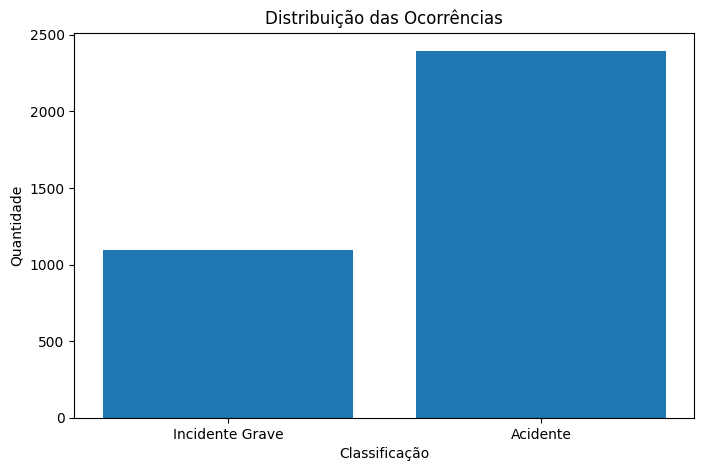

+---------------+-----+
|  Classificacao|count|
+---------------+-----+
|Incidente Grave| 1096|
|       Acidente| 2394|
+---------------+-----+



In [39]:
# ======================================================
# ANÁLISE 1: DISTRIBUIÇÃO DAS CLASSIFICAÇÕES
#
# Objetivo:
# Identificar a frequência dos tipos de ocorrência
# presentes na base de dados, permitindo verificar
# quais eventos apresentam maior incidência
# (Acidente ou Incidente Grave).
# ======================================================

import matplotlib.pyplot as plt

class_oc = ocorrencias.groupBy(
    "Classificacao"
).count()

dados = class_oc.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    dados["Classificacao"],
    dados["count"]
)

plt.xlabel("Classificação")

plt.ylabel("Quantidade")

plt.title(
    "Distribuição das Ocorrências"
)

plt.show()

class_oc.show()

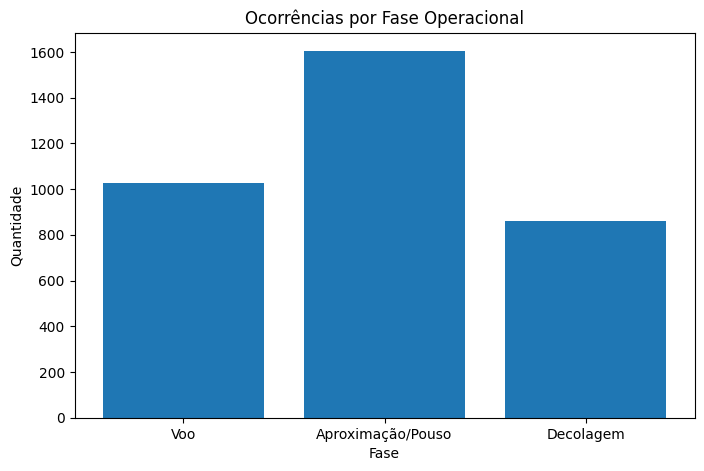

+-----------------+-----+
|             Fase|count|
+-----------------+-----+
|              Voo| 1026|
|Aproximação/Pouso| 1604|
|        Decolagem|  860|
+-----------------+-----+



In [40]:
# ======================================================
# ANÁLISE 2: DISTRIBUIÇÃO POR FASE OPERACIONAL
#
# Objetivo:
# Identificar em qual fase operacional
# (Decolagem, Voo ou Aproximação/Pouso)
# ocorre maior concentração de eventos.
#
# Essa análise auxilia na identificação
# das etapas mais críticas da operação aérea.
# ======================================================

fase_oc = ocorrencias.groupBy(
    "Fase"
).count()

dados = fase_oc.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    dados["Fase"],
    dados["count"]
)

plt.xlabel("Fase")

plt.ylabel("Quantidade")

plt.title(
    "Ocorrências por Fase Operacional"
)

plt.show()

fase_oc.show()

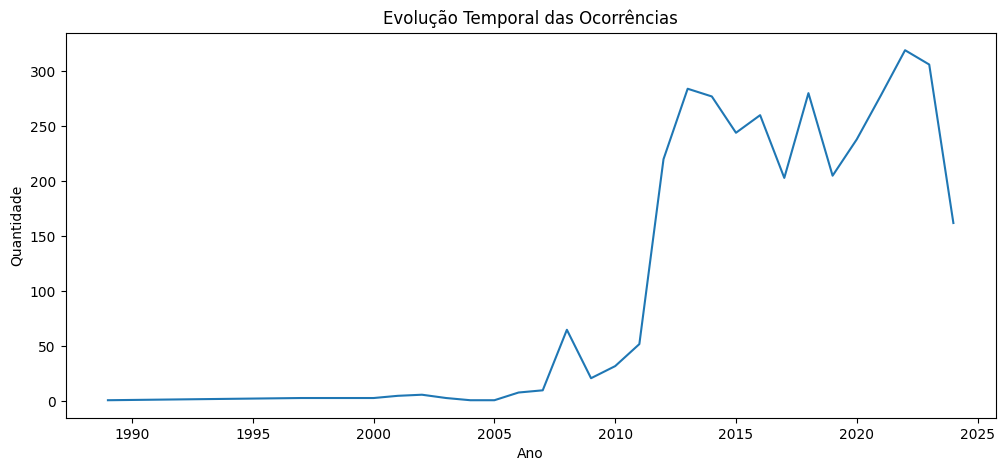

+----+-----+
| Ano|count|
+----+-----+
|1989|    1|
|1997|    3|
|1998|    3|
|2000|    3|
|2001|    5|
|2002|    6|
|2003|    3|
|2004|    1|
|2005|    1|
|2006|    8|
|2007|   10|
|2008|   65|
|2009|   21|
|2010|   32|
|2011|   52|
|2012|  220|
|2013|  284|
|2014|  277|
|2015|  244|
|2016|  260|
+----+-----+
only showing top 20 rows


In [41]:
# ======================================================
# ANÁLISE 3: TENDÊNCIA TEMPORAL
#
# Objetivo:
# Avaliar a evolução das ocorrências
# ao longo dos anos, identificando
# tendências de crescimento,
# estabilidade ou redução dos eventos.
# ======================================================

ano_oc = ocorrencias.groupBy(
    "Ano"
).count().orderBy(
    "Ano"
)

dados = ano_oc.toPandas()

plt.figure(figsize=(12,5))

plt.plot(
    dados["Ano"],
    dados["count"]
)

plt.xlabel("Ano")

plt.ylabel("Quantidade")

plt.title(
    "Evolução Temporal das Ocorrências"
)

plt.show()

ano_oc.show()

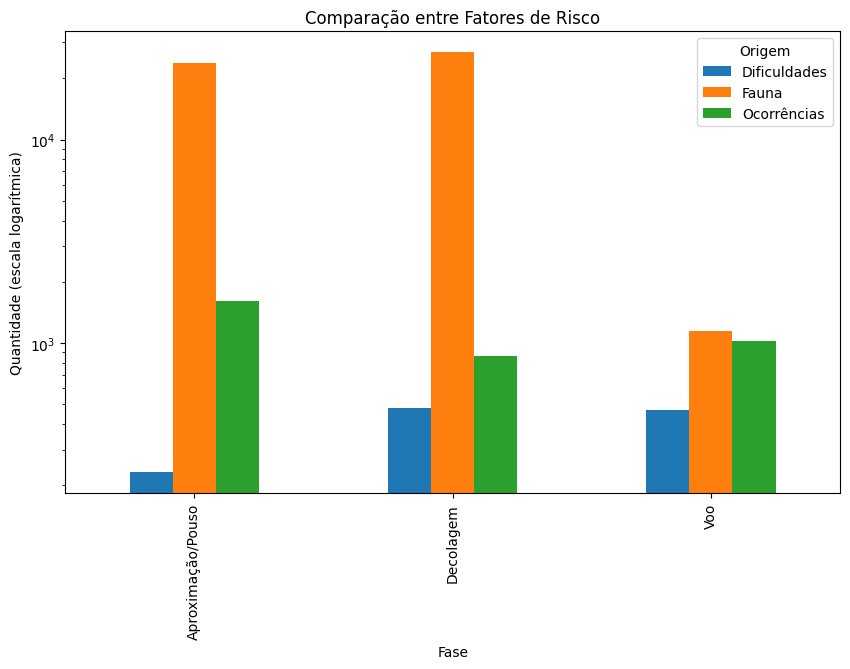

In [42]:
# ======================================================
# ANÁLISE 4: COMPARAÇÃO ENTRE FATORES DE RISCO
#
# Objetivo:
# Comparar eventos provenientes
# das três fontes de dados:
#
# - Ocorrências operacionais
# - Eventos com fauna
# - Dificuldades em serviço
#
# Foi aplicada escala logarítmica
# devido à grande diferença entre
# os volumes das bases.
# ======================================================

from pyspark.sql.functions import lit
import matplotlib.pyplot as plt

fase_oc = ocorrencias.groupBy(
    "Fase"
).count().withColumn(
    "Origem",
    lit("Ocorrências")
)

fase_fauna = fauna.groupBy(
    "Fase"
).count().withColumn(
    "Origem",
    lit("Fauna")
)

fase_dif = dificuldades.groupBy(
    "Fase"
).count().withColumn(
    "Origem",
    lit("Dificuldades")
)

comparacao = fase_oc.union(
    fase_fauna
).union(
    fase_dif
)

dados = comparacao.toPandas()

pivot = dados.pivot(
    index="Fase",
    columns="Origem",
    values="count"
)

ax = pivot.plot(
    kind="bar",
    figsize=(10,6),
    logy=True
)

plt.ylabel(
    "Quantidade (escala logarítmica)"
)

plt.title(
    "Comparação entre Fatores de Risco"
)

plt.show()

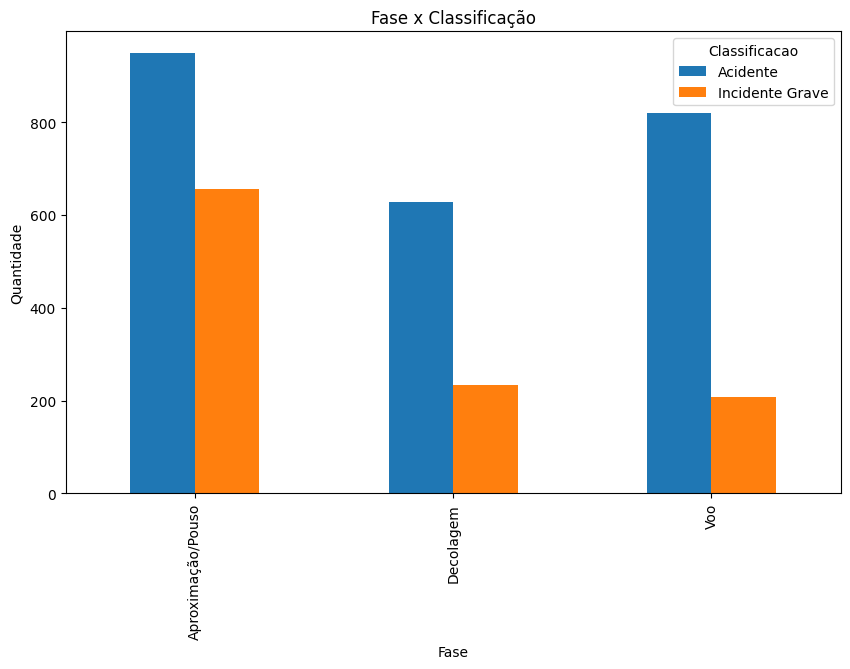

+-----------------+---------------+-----+
|             Fase|  Classificacao|count|
+-----------------+---------------+-----+
|Aproximação/Pouso|       Acidente|  948|
|        Decolagem|Incidente Grave|  233|
|        Decolagem|       Acidente|  627|
|Aproximação/Pouso|Incidente Grave|  656|
|              Voo|Incidente Grave|  207|
|              Voo|       Acidente|  819|
+-----------------+---------------+-----+



In [43]:
# ======================================================
# ANÁLISE 5: RELAÇÃO ENTRE FASE E CLASSIFICAÇÃO
#
# Objetivo:
# Avaliar a relação entre
# a classificação das ocorrências
# e a fase operacional,
# buscando identificar
# quais etapas apresentam
# maior severidade.
# ======================================================

cruzamento = ocorrencias.groupBy(
    "Fase",
    "Classificacao"
).count()

dados = cruzamento.toPandas()

pivot = dados.pivot(
    index="Fase",
    columns="Classificacao",
    values="count"
)

pivot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Quantidade")

plt.title(
    "Fase x Classificação"
)

plt.show()

cruzamento.show()

In [48]:
# ======================================================
# CRIAÇÃO DE CAMPO DE DATA PARA SÉRIE TEMPORAL
#
# Objetivo:
# Criar uma variável temporal compatível
# com ferramentas de visualização como
# Looker Studio.
# ======================================================

from pyspark.sql.functions import *

painel = painel.withColumn(
    "Data",
    to_date(
        concat(
            col("Ano"),
            lit("-01-01")
        )
    )
)

painel.toPandas().to_csv(
    "/content/drive/MyDrive/Ebac/painel_risco.csv",
    index=False
)

In [49]:
# ======================================================
# EXPORTAÇÃO DAS BASES DE DADOS TRATADAS
#
# Objetivo:
# Salvar as bases de dados após as etapas de
# limpeza, padronização e tratamento para
# utilização em ferramentas de visualização,
# como Looker Studio.
#
# O que o código faz:
# - Converte os DataFrames PySpark para o
#   formato Pandas;
# - Exporta cada base tratada para arquivos CSV;
# - Salva os arquivos automaticamente no
#   Google Drive;
# - Gera arquivos separados para:
#
#   • Ocorrências aeronáuticas
#   • Eventos envolvendo fauna
#   • Dificuldades em serviço
#
# Importância para o projeto:
# Esta etapa permite disponibilizar os dados
# tratados em um formato compatível com outras
# ferramentas analíticas, possibilitando a
# construção de dashboards e painéis interativos
# para análise dos fatores de risco em
# Segurança Operacional.
# ======================================================

# salvar ocorrências
ocorrencias.toPandas().to_csv(
    "/content/drive/MyDrive/Ebac/ocorrencias_final.csv",
    index=False
)

# salvar fauna
fauna.toPandas().to_csv(
    "/content/drive/MyDrive/Ebac/fauna_final.csv",
    index=False
)

# salvar dificuldades
dificuldades.toPandas().to_csv(
    "/content/drive/MyDrive/Ebac/dificuldades_final.csv",
    index=False
)

print("Arquivos exportados")

Arquivos exportados


In [50]:
# ======================================================
# PADRONIZAÇÃO FINAL DAS COLUNAS PARA UNIÃO DAS BASES
#
# Objetivo:
# Garantir que todas as tabelas possuam
# exatamente a mesma estrutura antes
# da integração dos dados.
#
# O que o código faz:
# - Seleciona apenas as colunas utilizadas
#   no painel:
#
#   • Classificacao
#   • Fase
#   • Ano
#
# - Cria a coluna "Origem";
# - Une as três bases;
# - Exporta o arquivo consolidado.
#
# Importância para o projeto:
# Esta etapa garante compatibilidade entre
# as bases e cria um conjunto de dados único
# para utilização no Looker Studio.
# ======================================================

from pyspark.sql.functions import lit

# selecionar somente colunas necessárias
oc = ocorrencias.select(
    "Classificacao",
    "Fase",
    "Ano"
).withColumn(
    "Origem",
    lit("Ocorrencias")
)

fa = fauna.select(
    "Classificacao",
    "Fase",
    "Ano"
).withColumn(
    "Origem",
    lit("Fauna")
)

dif = dificuldades.select(
    "Classificacao",
    "Fase",
    "Ano"
).withColumn(
    "Origem",
    lit("Dificuldades")
)

# unir tabelas
painel = oc.unionByName(
    fa
).unionByName(
    dif
)

# exportar
painel.toPandas().to_csv(
    "/content/drive/MyDrive/Ebac/painel_risco.csv",
    index=False
)

print("Painel consolidado exportado")

Painel consolidado exportado
